In [1]:
import pandas as pd

df = pd.read_csv("../../data/hard-water.txt", sep="\t")

In [24]:
import numpy as np

calcium = np.asarray(df["Calcium"], dtype="int")
mortality = np.asarray(df["Mortality"], dtype="int")

# Find means
calcium_bar = np.sum(calcium) / len(calcium)
mortality_bar = np.sum(mortality) / len(mortality)

print(calcium_bar)
print(mortality_bar)

47.18032786885246
1524.1475409836066


In [25]:
# Find std dev
s_calcium = np.sqrt(np.sum((calcium - calcium_bar) ** 2 / len(calcium) - 1))
s_mortality = np.sqrt(np.sum((mortality - mortality_bar) ** 2 / len(mortality) - 1))
print(s_calcium)
print(s_mortality)

# Continue next time


36.96431961341458
185.96018753059016


In [30]:
# Find the correlation
# you can use r = np.corrcoef(calcium, mortality)[0][1]
r = np.sum((calcium - np.mean(calcium)) * (mortality - np.mean(mortality))) / np.sqrt(np.sum((calcium - np.mean(calcium)) ** 2) * np.sum((mortality - np.mean(mortality)) ** 2))
print(r)

-0.6548486232042466


In [39]:
# lets create the slope and intercept
slope = r * (s_mortality / s_calcium)
intercept = np.mean(mortality) - slope * np.mean(calcium)

print(f"The linear equation is y = {intercept:.2f} + {slope:.2f}(x)")

# create a an array of predicted mortality values
mortality_pred = slope * calcium + intercept


The linear equation is y = 1679.58 + -3.29(x)


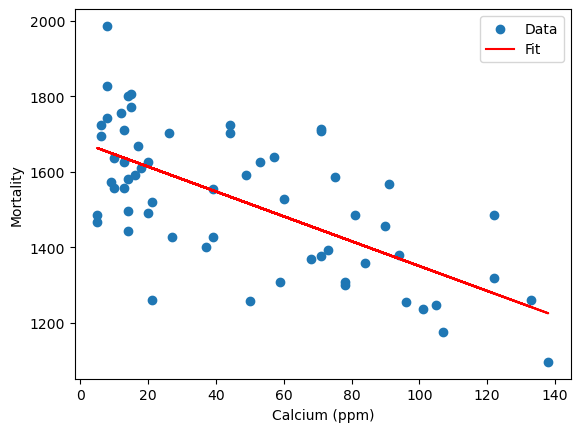

In [43]:
# lets graph it and see the scatter and regression
import matplotlib.pyplot as plt

# Plot
plt.scatter(calcium, mortality, label='Data')
plt.plot(calcium, mortality_pred, color='red', label='Fit')
plt.xlabel("Calcium (ppm)")
plt.ylabel("Mortality")
plt.legend()
plt.show()

In [44]:
# The hardness of one town’s municipal water is about 67 ppm of calcium. Use this equation to predict the mortality rate in that town.
prediction_67ppm_calcium = intercept + slope * 67
print(f"The model predicts {prediction_67ppm_calcium:.2f} deaths per 100,000 people.")

The model predicts 1458.85 deaths per 100,000 people.
